<a href="https://colab.research.google.com/github/SavindiPanditha/SE4050-Brain-Tumor-Classification/blob/feature%2Fmobilenetv2/02_MobileNetV2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/SE4050_DL_Assignment/Dataset"

print(os.listdir(project_path))

['dataset_config.py', 'dataset']


In [ ]:
import os
import pandas as pd

dataset_path = os.path.join(project_path, "dataset")
splits_path = os.path.join(dataset_path, "splits")

#checking files
print("Split files:", os.listdir(splits_path))

#loading the CSV files
train_df = pd.read_csv(os.path.join(splits_path, "train.csv"))
val_df = pd.read_csv(os.path.join(splits_path, "val.csv"))

#display
print("\nTraining images: ", len(train_df))
print("Validation images:", len(val_df))

print("\nColumn names:", train_df.columns.tolist())

print("\nFirst 5 training records:")
print(train_df.head())

Split files: ['train.csv', 'val.csv', 'test.csv', 'test.gsheet', 'train.gsheet']

Training images:  4480
Validation images: 1120

Column names: ['filepath', 'label', 'class_name']

First 5 training records:
                           filepath  label class_name
0  Training/pituitary/Tr-pi_135.jpg      3  Pituitary
1    Training/notumor/Tr-no_154.jpg      2   No Tumor
2     Training/glioma/Tr-gl_365.jpg      0     Glioma
3  Training/pituitary/Tr-pi_125.jpg      3  Pituitary
4     Training/glioma/Tr-gl_433.jpg      0     Glioma


Realative path:  Training/pituitary/Tr-pi_135.jpg
Full path:  /content/drive/MyDrive/SE4050_DL_Assignment/Dataset/dataset/Training/pituitary/Tr-pi_135.jpg
Image exists: True
Image size: (512, 512)
Image mode: RGB


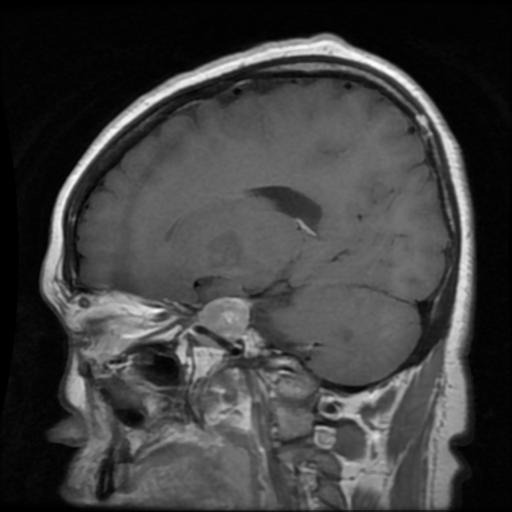

In [ ]:
import os
from PIL import Image

#main dataset
dataset_path = os.path.join(project_path, "dataset")

#get 1st image path - train.csv
relative_path = train_df.iloc[0]["filepath"]

image_path = os.path.join(dataset_path, relative_path)

print("Realative path: ", relative_path)
print("Full path: ", image_path)

#check the existense of image
print("Image exists:", os.path.isfile(image_path))

if os.path.isfile(image_path):
  with Image.open(image_path) as img:
    print("Image size:", img.size)
    print("Image mode:", img.mode)
    display(img.copy())
else:
  print("ERROR: Image not found! Chek the Dataset Path.")

In [ ]:
from pandas._libs import missing
#checking dataset size
print("Training images:", len(train_df))
print("Validation images:", len(val_df))

#class distribution checking
print("\nTraining class distribution:")
print(train_df.groupby(["label", "class_name"]).size())

print("\nValidation class distribution:")
print(val_df.groupby(["label", "class_name"]).size())

#training & validation image ovelap check
overlap = set(train_df["filepath"]) & set(val_df["filepath"])

print("\nOverlapping image paths:", len(overlap))

#verify images paths(few) from each class
for name, df in [("Training", train_df), ("Validation", val_df)]:
  sample = df.groupby("label").head(3)

  missing = [
      path for path in sample["filepath"]
      if not os.path.isfile(os.path.join(dataset_path, path))
  ]

  print(f"{name} sample missing images: ", len(missing))

Training images: 4480
Validation images: 1120

Training class distribution:
label  class_name
0      Glioma        1120
1      Meningioma    1120
2      No Tumor      1120
3      Pituitary     1120
dtype: int64

Validation class distribution:
label  class_name
0      Glioma        280
1      Meningioma    280
2      No Tumor      280
3      Pituitary     280
dtype: int64

Overlapping image paths: 0
Training sample missing images:  0
Validation sample missing images:  0


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import numpy as np


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

In [ ]:
def load_and_preprocess_image(filepath, label):

    # Convert bytes to string only if needed
    if isinstance(filepath, bytes):
        filepath = filepath.decode("utf-8")

    image_path = os.path.join(dataset_path, filepath)

    img = load_img(
        image_path,
        target_size=IMG_SIZE,
        color_mode="rgb"
    )

    img = img_to_array(img)

    img = tf.keras.applications.mobilenet_v2.preprocess_input(img)

    return img.astype(np.float32), label

In [ ]:
sample_image = train_df.iloc[0]["filepath"]
sample_label = train_df.iloc[0]["label"]

image, label = load_and_preprocess_image(
    sample_image,
    sample_label
)

print("Image shape:", image.shape)
print("Label:", label)

Image shape: (224, 224, 3)
Label: 3


In [ ]:
def create_dataset(df):

    filepaths = df["filepath"].values
    labels = df["label"].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (filepaths, labels)
    )

    def process_image(filepath, label):

        image, label = tf.numpy_function(
            load_and_preprocess_image,
            [filepath, label],
            [tf.float32, tf.int64]
        )

        # Tell TensorFlow the shapes
        image.set_shape([224, 224, 3])
        label.set_shape([])

        return image, label


    dataset = dataset.map(
        process_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.batch(BATCH_SIZE)

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [ ]:
train_dataset = create_dataset(train_df)

val_dataset = create_dataset(val_df)

print("Train dataset created")
print("Validation dataset created")

Train dataset created
Validation dataset created


In [ ]:
for images, labels in train_dataset.take(1):

  print("Image shape:", images.shape)
  print("Labels shape:", labels.shape)
  print("First labels:", labels[:5])

Image shape: (16, 224, 224, 3)
Labels shape: (16,)
First labels: tf.Tensor([3 2 0 3 0], shape=(5,), dtype=int64)


In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

print("MobileNetV2 base model loaded")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 base model loaded


In [ ]:
base_model.trainable = False

print("Base model frozen")

Base model frozen


In [ ]:
model = tf.keras.Sequential([

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        4,
        activation="softmax"
    )
])


print("MobileNetV2 classification model created")

MobileNetV2 classification model created


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss="sparse_categorical_crossentropy",

    metrics=[
        "accuracy"
    ]
)
print("Model complied successfully")

Model complied successfully


In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath="/content/drive/MyDrive/MobileNetV2_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)
print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[
        checkpoint,
        early_stop
    ]
)

Epoch 1/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.5651 - loss: 1.0277
Epoch 1: val_accuracy improved from None to 0.84732, saving model to /content/drive/MyDrive/MobileNetV2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/MobileNetV2_best.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 2783s 10s/step - accuracy: 0.7045 - loss: 0.7501 - val_accuracy: 0.8473 - val_loss: 0.4365
Epoch 2/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.8359 - loss: 0.4626
Epoch 2: val_accuracy improved from 0.84732 to 0.86786, saving model to /content/drive/MyDrive/MobileNetV2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/MobileNetV2_best.keras
280/280 ━━━━━━━━━━━━━━━━━━━━ 262s 935ms/step - accuracy: 0.8464 - loss: 0.4325 - val_accuracy: 0.8679 - val_loss: 0.3562
Epoch 3/10
280/280 ━━━━━━━━━━━━━━━━━━━━ 0s 764ms/step - accuracy: 0.8721 - loss: 0.3732
Epoch 3: val_accuracy improved from 0.86786 to 0.88393, saving model to /content/drive/MyDrive/MobileNe

In [25]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "/content/drive/MyDrive/MobileNetV2_training_history.csv",
    index=False
)
print("Training history saved")

Training history saved


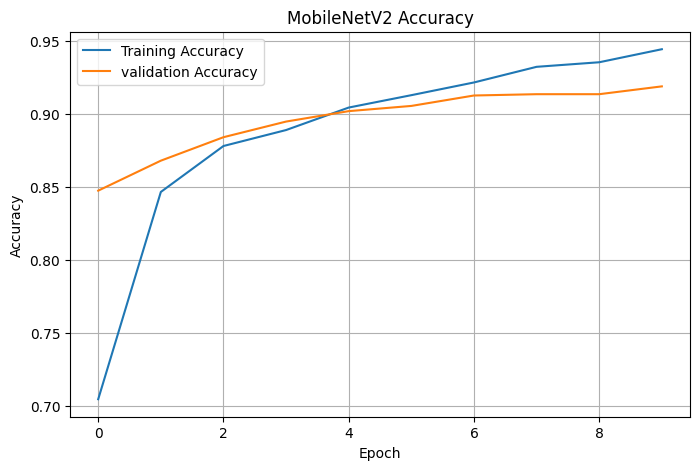

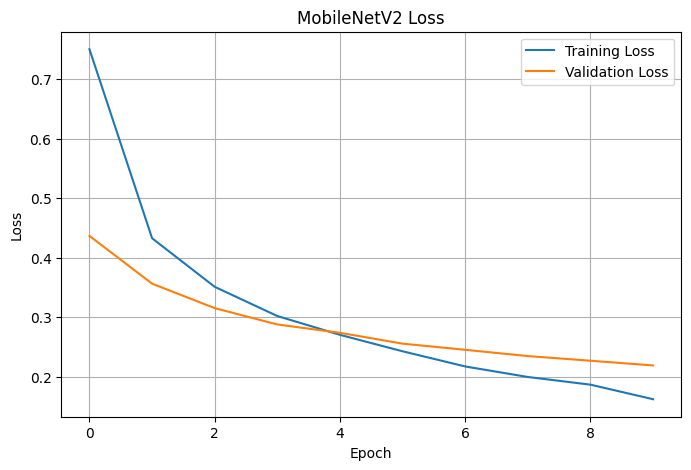

In [26]:
import matplotlib.pyplot as plt

#Accuracy graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="validation Accuracy"
)

plt.title("MobileNetV2 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

#Loss graph
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("MobileNetV2 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()